# Fase 1 — Limpieza de datos

**Objetivo:** dejar el dataset listo para construir secuencias temporales **sin inventar valores** y **sin borrar eventos reales**.

El taller advierte que el dataset tiene valores faltantes, anomalías, duplicados, desorden temporal e inconsistencias de texto. Aquí resolvemos cada problema en este orden, porque cada paso depende del anterior:

1. Duplicados → 2. Orden cronológico → 3. Texto/etiquetas → 4. Extremos (¿atípico o error?) → 5. Faltantes → 6. Guardar.

> **Principio rector.** Un valor *atípico* es raro comparado con el resto. Un valor *anómalo* es uno que **no pudo haber ocurrido**. Los picos de demanda reales son atípicos, y justamente lo que más nos interesa predecir. Si los borramos, el modelo aprende que los picos no existen. Por eso no eliminamos nada solo por ser raro.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

import limpieza as L
from graficos import aplicar_estilo, AZUL, NARANJA, AQUA, TINTA_2
aplicar_estilo()

RUTA_CRUDO = RAIZ / "data/raw/dataset_demanda_energia_LSTM_2025_2026.csv"
FIG = RAIZ / "resultados/figuras"
pd.set_option("display.width", 200)

## 1. Primer vistazo

Antes de tocar nada, miramos los datos tal como vienen. Fíjate en la columna `timestamp`: las filas **no están en orden**.

In [2]:
crudo = L.cargar_crudo(RUTA_CRUDO)
print("Filas x columnas:", crudo.shape)
crudo.head(6)

Filas x columnas: (17550, 15)


,timestamp,demanda_mw,temperatura_c,humedad_pct,viento_kmh,radiacion_wm2,precipitacion_mm,precio_kwh,hora,dia_semana,fin_semana,festivo,mes,periodo_dia,demanda_objetivo
0,2025-05-11 08:00:00,578.27,19.94,52.31,12.98,445.51,0.00,29.5028,8,6,1,0,5,mañana,573.67
1,2026-07-21 05:00:00,734.79,21.51,61.71,16.04,0.00,4.56,18.9739,5,1,0,0,7,madrugada,758.59
2,2025-08-21 00:00:00,698.80,24.00,94.25,16.15,0.00,0.00,18.9476,0,3,0,0,8,madrugada,705.37
3,2025-08-18 17:00:00,787.40,24.39,63.25,6.15,83.32,0.00,31.7882,17,0,0,0,8,tarde,804.35
4,2026-04-19 09:00:00,522.11,19.65,55.63,14.01,556.14,0.00,35.2807,9,6,1,0,4,mañana,526.36
5,2025-07-01 01:00:00,724.48,27.25,82.23,13.94,0.00,0.00,18.2553,1,1,0,0,7,madrugada,731.26


In [3]:
pd.DataFrame({"tipo": crudo.dtypes, "nulos": crudo.isna().sum()})

,tipo,nulos
timestamp,datetime64[us],0
demanda_mw,float64,0
temperatura_c,float64,70
humedad_pct,float64,70
viento_kmh,float64,71
radiacion_wm2,float64,0
precipitacion_mm,float64,0
precio_kwh,float64,70
hora,int64,0
dia_semana,int64,0


## 2. Duplicados

**Qué:** filas idénticas en todas las columnas.
**Por qué eliminarlas:** una hora repetida pesaría el doble en el entrenamiento. Además, rompe la regla de que cada paso de la secuencia equivale a 1 hora, que es la base de una LSTM.
**Verificación de seguridad:** después de eliminarlas no deben quedar timestamps repetidos *con valores distintos*. Si quedaran, no sabríamos cuál fila es la correcta.

In [4]:
df, n_dup = L.eliminar_duplicados(crudo)
print(f"Duplicados exactos eliminados: {n_dup}")
print(f"Timestamps repetidos restantes: {df['timestamp'].duplicated().sum()}")

Duplicados exactos eliminados: 30
Timestamps repetidos restantes: 0


## 3. Orden cronológico y rejilla horaria

**Por qué:** una LSTM lee la secuencia en orden. Interpreta la posición *i* como "la hora anterior a *i+1*". Con las filas desordenadas, el modelo aprendería relaciones entre horas que no son consecutivas.

También verificamos que no falte ninguna hora entre el inicio y el fin del periodo. Un hueco haría que dos filas contiguas no estuvieran separadas por 1 hora.

In [5]:
df, faltantes = L.ordenar_y_verificar(df)
print("Desde", df.timestamp.min(), "hasta", df.timestamp.max())
print("Horas esperadas:", len(pd.date_range(df.timestamp.min(), df.timestamp.max(), freq="h")),
      "| filas:", len(df), "| horas faltantes:", len(faltantes))
print("¿Estrictamente creciente?", df.timestamp.is_monotonic_increasing and df.timestamp.is_unique)

Desde 2025-01-01 00:00:00 hasta 2026-12-31 23:00:00
Horas esperadas: 17520 | filas: 17520 | horas faltantes: 0
¿Estrictamente creciente? True


Las columnas de calendario (`hora`, `dia_semana`, `mes`, `fin_semana`) se derivan del timestamp. Comprobamos que coincidan, para saber si podemos confiar en ellas.

In [6]:
ts = df.timestamp
pd.Series({
    "hora": (df.hora != ts.dt.hour).sum(),
    "dia_semana": (df.dia_semana != ts.dt.dayofweek).sum(),
    "mes": (df.mes != ts.dt.month).sum(),
    "fin_semana": (df.fin_semana != (ts.dt.dayofweek >= 5).astype(int)).sum(),
}, name="filas incoherentes")

hora          0
dia_semana    0
mes           0
fin_semana    0
Name: filas incoherentes, dtype: int64

## 4. Inconsistencias de texto: `periodo_dia`

Hay dos problemas distintos:
- **Formato:** `' noche '`, `'TARDE'`, `'Mañana'` son la misma categoría escrita de otra forma. Se resuelve con `strip()` + `lower()`.
- **Contenido:** algunas filas dicen "tarde" a las 2 a. m. Como `periodo_dia` se **deriva** de la hora (y la hora ya está verificada contra el timestamp), la recalculamos con una regla fija: madrugada 0–5, mañana 6–11, tarde 12–17, noche 18–23.

¿Esto es "inventar"? No. Se reconstruye una etiqueta a partir de su fuente verdadera, igual que calcular el mes a partir de la fecha.

In [7]:
print(df.periodo_dia.value_counts().to_string())
tabla = pd.crosstab(df.hora, df.periodo_dia.str.strip().str.lower())
tabla.T

periodo_dia
noche        4363
tarde        4361
madrugada    4358
mañana       4358
Mañana         20
 noche         20
TARDE          20
MAÑANA         20


hora,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
periodo_dia,,,,,,,,,,,,,,,,,,,,,
madrugada,725,724,730,728,724,727,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
mañana,1,3,0,1,4,2,729,728,729,728,...,1,2,1,1,0,1,2,4,2,1
noche,2,2,0,0,0,0,1,1,1,1,...,4,1,0,1,730,729,727,726,727,729
tarde,2,1,0,1,2,1,0,1,0,1,...,725,727,729,728,0,0,1,0,1,0


In [8]:
df, n_texto, n_incoh = L.corregir_periodo_dia(df)
print(f"Etiquetas con formato corregido: {n_texto} | incoherentes con la hora: {n_incoh}")
df.periodo_dia.value_counts()

Etiquetas con formato corregido: 80 | incoherentes con la hora: 60


periodo_dia
madrugada    4380
mañana       4380
tarde        4380
noche        4380
Name: count, dtype: int64

## 5. Descubrimiento clave: ¿qué es `demanda_objetivo`?

Para definir bien el problema, verificamos qué representa la columna objetivo. La hipótesis es que `demanda_objetivo(t)` es la demanda de la **hora siguiente**, es decir, `demanda_mw(t+1)`.

In [9]:
coincide = (df.demanda_objetivo - df.demanda_mw.shift(-1)).abs() < 0.01
print(f"demanda_objetivo(t) == demanda_mw(t+1) en el {coincide.iloc[:-1].mean():.2%} de las filas")
print(f"Filas donde NO coinciden: {(~coincide.iloc[:-1]).sum()}")

demanda_objetivo(t) == demanda_mw(t+1) en el 99.77% de las filas
Filas donde NO coinciden: 40


**Conclusión:** se confirma la hipótesis. Esto tiene tres consecuencias:
1. **Variable dependiente (y) = `demanda_objetivo`.** Es exactamente lo que pide el taller: la demanda de la siguiente hora.
2. **Fuga de información:** `demanda_objetivo` de la fila *t* **nunca** puede ser entrada del modelo, porque es la respuesta.
3. **Tenemos dos mediciones de cada hora:** `demanda_mw(t)` y `demanda_objetivo(t−1)`. Si no coinciden, una de las dos está mal. Esta es la base de la *prueba de consistencia*.

## 6. ¿Por qué NO usar IQR o z-score para "limpiar outliers"?

Es el método que más aparece en tutoriales. Veamos qué pasaría si lo aplicamos a la columna objetivo, que ya sabemos que está limpia.

In [10]:
y = df.demanda_objetivo
q1, q3 = y.quantile([.25, .75]); iqr = q3 - q1
iqr_flag = (y < q1 - 1.5 * iqr) | (y > q3 + 1.5 * iqr)
print(f"IQR marcaría {iqr_flag.sum()} horas de la columna objetivo como 'outliers'")
print("Ejemplos de lo que borraría:")
df.loc[iqr_flag & (y > q3), ["timestamp", "demanda_objetivo", "temperatura_c"]].sort_values(
    "demanda_objetivo", ascending=False).head(8)

IQR marcaría 9 horas de la columna objetivo como 'outliers'
Ejemplos de lo que borraría:


,timestamp,demanda_objetivo,temperatura_c
4938,2025-07-25 18:00:00,927.31,28.73
13146,2026-07-02 18:00:00,913.67,27.46
4386,2025-07-02 18:00:00,913.33,28.52


El método IQR marcaría como "outliers" picos reales de demanda en días calurosos, que son justo los que el modelo debe aprender a predecir. Además, compara cada valor contra **todo** el dataset, incluido el periodo de test (fuga sutil de información).

Por eso usamos un **protocolo de cuatro pruebas**. Un valor solo se considera error si falla con evidencia clara:

| # | Prueba | Idea | Ejemplo |
|---|---|---|---|
| 1 | **Física** | ¿Puede existir este valor? | Humedad de 129 % → no |
| 2 | **Contexto temporal** | ¿Tiene continuidad con la hora anterior y la siguiente? | 9 °C → 45 °C → 9 °C en una hora → no |
| 3 | **Consistencia interna** | ¿Coinciden las dos mediciones de la misma hora? | `demanda_mw` = 1 776 vs. `demanda_objetivo(t−1)` = 721 → no |
| 4 | **Coherencia causal** | ¿Tiene una causa razonable? | Precio récord a la 1 a. m. con demanda baja → no |

### Cómo funciona la prueba 2 (contexto temporal)

Para cada hora calculamos:
- **desvío** = |valor − promedio(hora anterior, hora siguiente)|
- **entre vecinos** = |hora anterior − hora siguiente|

Un valor es un **pico aislado** si:
- **(a)** su desvío es mucho mayor que lo normal: más de *mediana + 10·MAD* del desvío, calculado **solo con datos de entrenamiento**;
- **(b)** sus vecinos coinciden entre sí más de lo que coinciden con él.

La condición (b) evita marcar a los vecinos de un pico, que también parecen "alejados" de su propio promedio.

La prueba solo se aplica a variables con **inercia física** (temperatura, humedad, viento promedio horario). No se aplica a la lluvia ni a la radiación, que cambian de golpe por naturaleza (empieza a llover, pasa una nube).

El factor 10 es **conservador** a propósito: preferimos dejar pasar un error leve que borrar un dato real.

In [11]:
filas = []
for col in ["temperatura_c", "humedad_pct", "viento_kmh", "precio_kwh"]:
    _, _, desvio, _ = L._vecinos(df[col])
    marca, umbral = L.pico_aislado(df, col)
    filas.append({"variable": col, "desvío típico (mediana)": round(desvio.median(), 2),
                  "p99 desvío": round(desvio.quantile(.99), 2), "umbral (10·MAD)": round(umbral, 2),
                  "picos aislados": int(marca.sum())})
pd.DataFrame(filas)

,variable,desvío típico (mediana),p99 desvío,umbral (10·MAD),picos aislados
0,temperatura_c,1.07,4.71,10.57,34
1,humedad_pct,4.15,16.75,40.79,17
2,viento_kmh,2.47,10.56,24.44,24
3,precio_kwh,2.15,8.77,21.04,15


## 7. Clasificación de todos los valores sospechosos

In [12]:
auditoria = L.clasificar_extremos(df, precio_extremo_es_error=True)
auditoria.groupby(["variable", "prueba", "veredicto"]).size().rename("casos").to_frame()

casos
variable      prueba                    veredicto       
demanda_mw    3-consistencia            dudoso         7
              3-consistencia+2-contexto error         33
humedad_pct   1-fisica                  error          9
              2-contexto                error         11
precio_kwh    2-contexto+4-causas       error         15
temperatura_c 2-contexto                error         34
viento_kmh    1-fisica                  error          8
              1-fisica+2-contexto       error         13
              2-contexto                dudoso        11

La tabla de auditoría guarda **cada** valor marcado con su contexto. Así cualquiera puede revisar la decisión. Algunos ejemplos:

In [13]:
auditoria.groupby("variable").head(3)

,timestamp,variable,anterior,valor,siguiente,prueba,veredicto
0,2025-01-08 13:00:00,demanda_mw,514.6600,1192.54,533.2300,3-consistencia+2-contexto,error
1,2025-01-29 14:00:00,demanda_mw,591.8200,443.67,593.1100,3-consistencia,dudoso
2,2025-05-13 20:00:00,demanda_mw,855.4200,1092.31,790.5800,3-consistencia+2-contexto,error
40,2025-01-10 03:00:00,humedad_pct,90.7500,16.45,87.6700,2-contexto,error
41,2025-02-21 14:00:00,humedad_pct,66.0300,7.05,71.6800,2-contexto,error
42,2025-07-12 22:00:00,humedad_pct,79.2400,116.56,83.3100,1-fisica,error
60,2025-01-12 01:00:00,precio_kwh,22.8112,63.96,25.4840,2-contexto+4-causas,error
61,2025-02-04 03:00:00,precio_kwh,16.4139,47.50,19.3595,2-contexto+4-causas,error
62,2025-05-26 00:00:00,precio_kwh,26.4074,54.28,22.5262,2-contexto+4-causas,error
75,2025-01-09 09:00:00,temperatura_c,9.3600,44.94,9.5100,2-contexto,error


**Observa los casos de temperatura dentro del rango normal.** Por ejemplo, 27.4 °C a las 23 h en enero, entre dos lecturas de 14.5 °C. Una regla de rangos ("temperatura entre −5 y 40") **no lo habría detectado**, porque 27 °C es una temperatura normal. Es un error solo por su **contexto**. Al revés, un valor globalmente raro pero sostenido y coherente se conserva.

## 8. Veámoslo: errores vs. picos reales

Las gráficas lo hacen evidente. Un error dura una sola hora y regresa de inmediato. Un pico real sube en rampa, dura varias horas y tiene una causa: el calor.

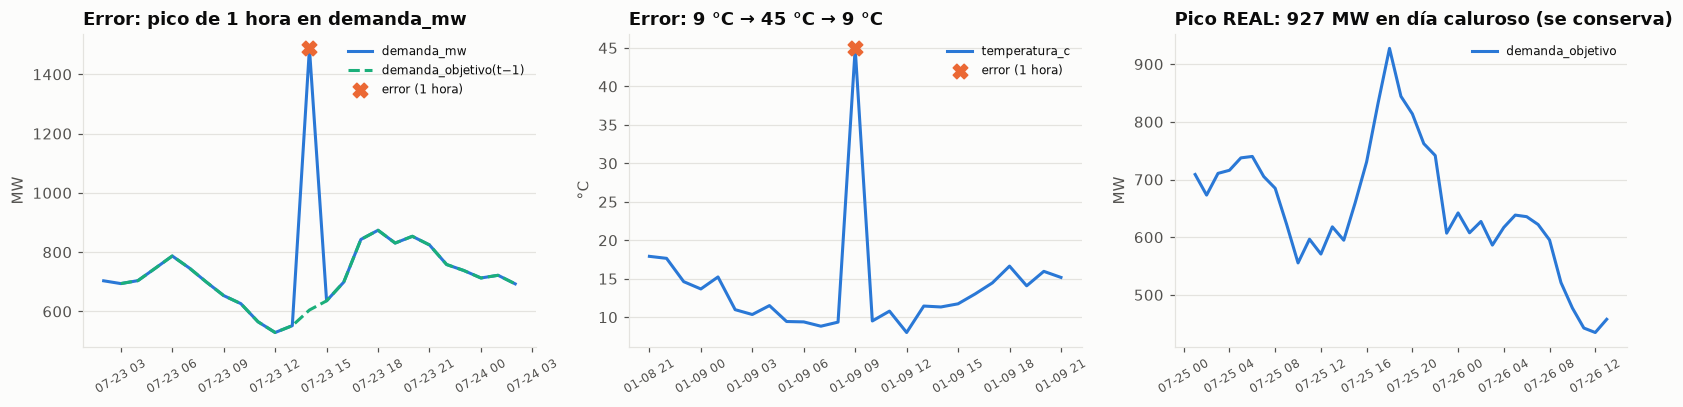

In [14]:
def ventana(ts, horas=12):
    t = pd.Timestamp(ts)
    return df[(df.timestamp >= t - pd.Timedelta(hours=horas)) & (df.timestamp <= t + pd.Timedelta(hours=horas))]

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))

w = ventana("2025-07-23 14:00")
ax[0].plot(w.timestamp, w.demanda_mw, color=AZUL, label="demanda_mw")
ax[0].plot(w.timestamp, w.demanda_objetivo.shift(1), color=AQUA, linestyle="--", label="demanda_objetivo(t−1)")
e = w[w.timestamp == "2025-07-23 14:00"]
ax[0].scatter(e.timestamp, e.demanda_mw, color=NARANJA, marker="X", s=90, zorder=3, label="error (1 hora)")
ax[0].set_title("Error: pico de 1 hora en demanda_mw"); ax[0].set_ylabel("MW"); ax[0].legend(fontsize=8)

w = ventana("2025-01-09 09:00")
ax[1].plot(w.timestamp, w.temperatura_c, color=AZUL, label="temperatura_c")
e = w[w.timestamp == "2025-01-09 09:00"]
ax[1].scatter(e.timestamp, e.temperatura_c, color=NARANJA, marker="X", s=90, zorder=3, label="error (1 hora)")
ax[1].set_title("Error: 9 °C → 45 °C → 9 °C"); ax[1].set_ylabel("°C"); ax[1].legend(fontsize=8)

w = ventana("2025-07-25 19:00", horas=18)
ax[2].plot(w.timestamp, w.demanda_objetivo, color=AZUL, label="demanda_objetivo")
ax[2].set_title("Pico REAL: 927 MW en día caluroso (se conserva)"); ax[2].set_ylabel("MW"); ax[2].legend(fontsize=8)

for a in ax:
    a.tick_params(axis="x", rotation=30, labelsize=8)
plt.tight_layout(); plt.savefig(FIG / "01_errores_vs_picos_reales.png"); plt.show()

In [15]:
# Los días de mayor demanda coinciden con los días más calurosos: son eventos reales.
diario = df.set_index("timestamp").resample("D").agg(demanda_max=("demanda_objetivo", "max"),
                                                      temp_max=("temperatura_c", "max"))
diario.sort_values("demanda_max", ascending=False).head(8).round(1)

,demanda_max,temp_max
timestamp,,
2025-07-25,927.3,28.8
2026-07-02,913.7,32.2
2025-07-02,913.3,31.3
2026-05-27,911.1,31.0
2026-07-06,909.6,30.6
2025-07-08,909.1,31.5
2025-06-11,906.7,30.9
2026-05-12,905.7,28.2


## 9. Aplicar la limpieza

- Los valores con veredicto **error** pasan a `NaN`. **No se reemplazan** por promedios ni por interpolación.
- Los **dudosos** del viento (rachas posibles por debajo de 80 km/h) **se conservan**.
- **Demanda.** Se comparan dos tratamientos (experimento del taller):
  - **A (estricto):** `demanda_mw` = NaN en las 40 horas en conflicto. Las ventanas que las contengan se descartan.
  - **B (recuperación):** `demanda_mw_recuperada` toma el valor de `demanda_objetivo(t−1)`. Es **la otra medición real de esa misma hora**, registrada en el dataset, no un valor estimado.

In [16]:
limpio = L.aplicar_limpieza(df, auditoria)
pd.DataFrame({"NaN antes": df.isna().sum(), "NaN después": limpio.isna().sum()}).query("`NaN después` > 0")

,NaN antes,NaN después
demanda_mw,0.0,40
demanda_objetivo,1.0,1
humedad_pct,70.0,90
precio_kwh,70.0,85
temperatura_c,70.0,104
viento_kmh,70.0,91


## 10. Valores faltantes de las variables exógenas: el dilema

La regla del taller dice: *"no inventar valores para corregir anomalías"*. La opción más estricta es descartar toda ventana que contenga un NaN. Veamos cuánto cuesta eso según el tamaño de la ventana:

In [17]:
exog = ["temperatura_c", "humedad_pct", "viento_kmh", "precio_kwh"]
malo_exog = limpio[exog].isna().any(axis=1).astype(int).values
malo_total = (limpio[exog].isna().any(axis=1) | limpio.demanda_mw.isna()).astype(int).values
filas = []
for n in (12, 24, 48):
    k = np.ones(n, int)
    filas.append({"ventana (h)": n,
                  "% ventanas válidas (descartando NaN exógenos)": 100 * (np.convolve(malo_exog, k, "valid") == 0).mean(),
                  "% ventanas válidas (descartando todo)": 100 * (np.convolve(malo_total, k, "valid") == 0).mean()})
pd.DataFrame(filas).round(1)

,ventana (h),% ventanas válidas (descartando NaN exógenos),% ventanas válidas (descartando todo)
0,12,77.5,75.3
1,24,59.3,55.9
2,48,34.6,30.8


Con descarte estricto, la ventana de 48 h perdería gran parte de los datos. Eso **sesgaría la comparación de ventanas** que pide el taller: la de 48 h entrenaría con mucho menos.

**Solución propuesta: *forward-fill* causal (máximo 3 horas) + bandera.**
- Repite el **último valor conocido**. Es lo que haría un sistema real en tiempo real cuando un sensor no reporta: usar la última lectura.
- **No usa el futuro.** Interpolar sí lo haría: la interpolación lineal necesita el valor *siguiente*, y eso es fuga de información.
- **No fabrica valores nuevos.** Solo reutiliza uno observado.
- Una bandera `flag_exogena_rellenada` le indica al modelo que ese dato no es fresco.
- Huecos de más de 3 horas se dejarían en NaN y sus ventanas se descartarían. Ya veremos que no hay ninguno.

> ⚠️ **Decisión para validar con el docente.** Si no acepta el ffill, la alternativa estricta ya está cuantificada en la tabla de arriba.

El ffill se aplica en la Fase 3, al preparar las secuencias. Aquí guardamos el dataset con los NaN explícitos para que todo quede auditable.

In [18]:
prueba = L.rellenar_exogenas_causal(limpio)
print("NaN exógenos que quedarían tras ffill (huecos > 3 h):", int(prueba[exog].isna().sum().sum()))
print("Horas con algún valor rellenado:", int(prueba.flag_exogena_rellenada.sum()))

NaN exógenos que quedarían tras ffill (huecos > 3 h): 0
Horas con algún valor rellenado: 367


## 11. Última hora sin objetivo

`2026-12-31 23:00` no tiene `demanda_objetivo`, porque su "hora siguiente" ya está fuera del dataset. **No borramos la fila:** sus variables son válidas como contexto de entrada. Simplemente nunca se usará como objetivo. Si la borráramos, no cambiaría nada aquí, pero borrar filas a mitad de la serie rompería la rejilla horaria. Es un buen hábito no hacerlo.

## 12. Guardar resultados

In [19]:
(RAIZ / "data/processed").mkdir(parents=True, exist_ok=True)
limpio.to_parquet(RAIZ / "data/processed/dataset_limpio.parquet", index=False)
auditoria.to_csv(RAIZ / "resultados/auditoria_limpieza.csv", index=False)

_, _, resumen = L.limpiar(RUTA_CRUDO)
for k, v in resumen.items():
    print(f"{k:35s} {v}")

filas_crudas                        17550
duplicados_eliminados               30
horas_faltantes_en_rejilla          0
periodo_dia_texto_corregido         80
periodo_dia_incoherente_con_hora    60
nulos_originales                    {'temperatura_c': 70, 'humedad_pct': 70, 'viento_kmh': 70, 'precio_kwh': 70, 'demanda_objetivo': 1}
objetivo_nulo                       ['2026-12-31 23:00:00']
filas_finales                       17520


## Resumen para el informe

| Problema | Regla aplicada | Justificación |
|---|---|---|
| 30 duplicados | Eliminar filas idénticas | Una hora no puede pesar doble; se mantiene 1 paso = 1 hora |
| Filas desordenadas | Ordenar por `timestamp`; rejilla horaria completa verificada | La LSTM interpreta la posición como tiempo |
| `periodo_dia` (formato y 60 incoherencias) | Recalcular desde `hora` | Es una etiqueta derivada; la hora es la fuente verificada |
| Temperatura y humedad imposibles o aisladas | NaN (pruebas 1 y 2) | Inercia física; no se reemplaza por nada |
| Viento < 0 o > 80 km/h aislado | NaN | Imposible, o una "tormenta de 1 hora" |
| Viento 25–80 km/h aislado | **Se conserva** (dudoso) | Podría ser una ráfaga real |
| Precio extremo aislado | NaN (pruebas 2 y 4); experimento de sensibilidad | No coincide con demanda alta |
| 40 conflictos en `demanda_mw` | Tratamiento A (NaN) vs. B (otra medición real) | Prueba de consistencia interna |
| Picos reales de demanda (hasta 927 MW) | **Se conservan** | Son eventos reales; el modelo debe aprenderlos |
| Faltantes exógenos | ffill causal ≤ 3 h + bandera (en la Fase 3) | Sin futuro y sin fabricar valores; evita sesgar la comparación de ventanas |